# Elliptic Dataset: Baseline Modeling

Can simple graph features improve fraud detection under a strict temporal split?

This project will do a baseline modeling using a temporal split and report to see if there's leakage or robust and understand what this feature is telling us.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

import networkx as nx

from scipy.stats import spearmanr

In [2]:
# Mount the data sets
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 3 data sets:
df_classes = pd.read_csv('/content/drive/MyDrive/elliptic_txs_classes.csv')
df_edgelist = pd.read_csv('/content/drive/MyDrive/elliptic_txs_edgelist.csv')
df_features = pd.read_csv('/content/drive/MyDrive/elliptic_txs_features.csv', header=None) # need a header

#### `df_classes`

In [4]:
df_classes

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown
...,...,...
203764,173077460,unknown
203765,158577750,unknown
203766,158375402,1
203767,158654197,unknown


In [5]:
# using .map for 1-illict and 2-licit
df_classes['class'] = pd.to_numeric(df_classes['class'], errors='coerce')
df_classes['class'] = df_classes['class'].map({1: 'illicit', 2: 'licit'}).fillna('unknown')

print(df_classes['class'].value_counts(1))

class
unknown    0.771486
licit      0.206209
illicit    0.022305
Name: proportion, dtype: float64


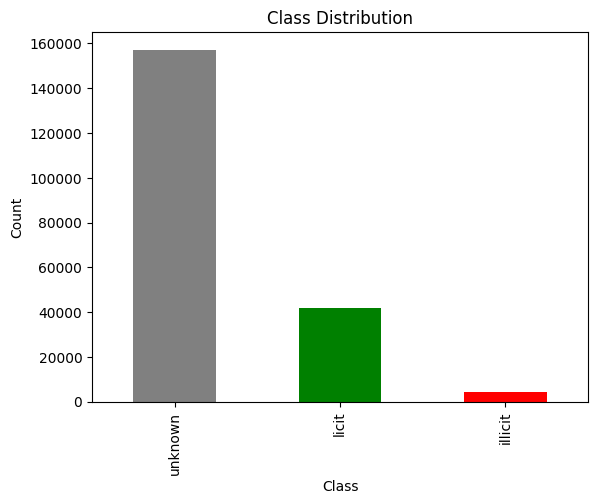

In [6]:
# visual for df_classes
df_classes['class'].value_counts().plot(kind='bar', title='Class Distribution', color=['gray', 'green', 'red'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

#### `df_edgelist`

In [7]:
df_edgelist = df_edgelist.rename(columns={'txId1': 'source', 'txId2':'target'})

In [8]:
df_edgelist

,source,target
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


#### `df_features`

In [9]:
df_features

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.577099,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.162722,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.261246,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.397749,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399


## Temporal Split

To reduce temporal leakage, I used a strict chronological split based on the time_step variable. Since the Elliptic dataset represents transaction activity evolving over time, random train-test splits could allow future transaction behavior to leak into the training process.

The split was defined as:

Training: time steps 1–34
Validation: time steps 35–39
Test: time steps 40–49
This setup better simulates a real-world fraud detection scenario where models are trained on historical transaction behavior and evaluated on future unseen activity.

In [10]:
# rename class = label
df_classes = df_classes.rename(columns={'class': 'label'})

#rename feature columns for clarity
# Column 0 is txId, Column 1 is time_step. The rest are features.
df_features = df_features.rename(columns={0: 'txId', 1: 'time_step'})

# merge labels into df_features
# The 'label' column from df_classes will be added to df_features
df_features = df_features.merge(df_classes[['txId', 'label']], on='txId', how='left')

# temporal split
train_df = df_features[df_features['time_step'] <= 34].copy()
val_df = df_features[(df_features['time_step'] >= 35) & (df_features['time_step'] <= 39)].copy()
test_df = df_features[df_features['time_step'] >= 40].copy()

print(f"Training set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"Trainng set Time Step Range: {train_df['time_step'].min(), train_df['time_step'].max()}")
print(f"Validation set Time Step Range: {val_df['time_step'].min(), val_df['time_step'].max()}")
print(f"Test set Time Step Range: {test_df['time_step'].min(), test_df['time_step'].max()}")

Training set shape: (136265, 168)
Validation set shape: (20857, 168)
Test set shape: (46647, 168)
Trainng set Time Step Range: (1, 34)
Validation set Time Step Range: (35, 39)
Test set Time Step Range: (40, 49)


The resulting split sizes were:

- Training set: 136,265 transactions
- Validation set: 20,857 transactions
- Test set: 46,647 transactions

This preserved the chronological ordering of the transaction graph while providing sufficient data for training and evaluation. Furthermore, the temporal split better reflects real-world fraud detection settings, where models must generalize from historical transaction patterns to future unseen activity.

## Logistic Regression

This section presents a baseline logistic regression model using all 166 features from the Elliptic dataset. The goal is to establish an initial benchmark.


In [11]:
feature_cols = [c for c in df_features.columns if c not in ['txId', 'time_step', 'label']]
print(len(feature_cols))

165


In [12]:
# Now, filter ou 'unknown' labels
train_df = train_df[train_df['label'] != 'unknown'].copy()
val_df = val_df[val_df['label'] != 'unknown'].copy()
test_df = test_df[test_df['label'] != 'unknown'].copy()

# create X and y
X_train = train_df[feature_cols]
y_train = train_df['label']

X_val = val_df[feature_cols]
y_val = val_df['label']

X_test = test_df[feature_cols]
y_test = test_df['label']

# Train Model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [13]:
# val predictions
val_preds = lr_model.predict(X_val)
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

     illicit       0.27      0.95      0.42       447
       licit       0.99      0.77      0.87      5039

    accuracy                           0.78      5486
   macro avg       0.63      0.86      0.64      5486
weighted avg       0.94      0.78      0.83      5486



The logistic regression classifier achieved a validation accuracy of 0.78. The validation F1-score for illicit transactions was 0.42, while the F1-score for licit transactions was 0.87. Overall the model appears reasonable stable and does not suggest leakage.

## Random Forest

In [14]:
# random forest
rf_model = RandomForestClassifier(n_estimators=300,
                                  max_depth=None,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1)

rf_model.fit(X_train, y_train)

# validation
rf_val_preds = rf_model.predict(X_val)
print(classification_report(y_val, rf_val_preds))

rf_val_f1 = f1_score(y_val, rf_val_preds, pos_label='illicit')
print("Random Forest Validation Illicit F1", rf_val_f1)

              precision    recall  f1-score   support

     illicit       0.99      0.89      0.94       447
       licit       0.99      1.00      0.99      5039

    accuracy                           0.99      5486
   macro avg       0.99      0.94      0.97      5486
weighted avg       0.99      0.99      0.99      5486

Random Forest Validation Illicit F1 0.9372781065088758


The Random Forest baseline achieved a validation accuracy of 0.99, with an illicit transaction F1-score of 0.94. This performance is extremely high and raises suspicion of potential leakage or strong temporal feature encoding.

## Degree

Degree measures the number of connections associated with each transaction node in the network. For this analysis, the transaction graph was treated as a undirected graph, and degree was computed as the number of neighboring nodes connected to each transaction.


In [15]:
# create edgelist
G = nx.from_pandas_edgelist(
    df_edgelist,
    source='source',
    target='target',
    create_using=nx.Graph())

# compute degree for each node
degree_dict = dict(G.degree())

# add degree feature to node dataframe
df_features['degree'] = df_features['txId'].map(degree_dict)

# fill missing values
df_features['degree'] = df_features['degree'].fillna(0).astype(int)

# check
df_features[['txId', 'degree']].head()

,txId,degree
0,230425980,2
1,5530458,2
2,232022460,3
3,232438397,161
4,230460314,10


### Degree Distribution

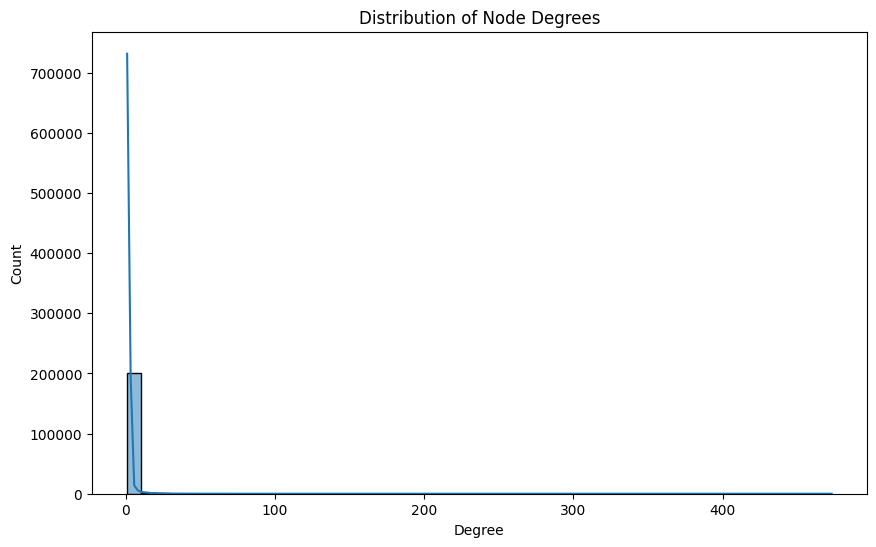

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df_features['degree'], bins=50, kde=True)
plt.title('Distribution of Node Degrees')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.show()

The raw degree distribution is highly right-skewed. Most transactions have very few connections, while a small number of nodes act as highly connected hubs.

To better visualize the distribution, a log-log plot was created. The log-log view reveals a long-tailed structure that is common in many real-world networks, including financial transaction networks. Most nodes have low degree values, while a relatively small number of nodes have substantially higher connectivity.

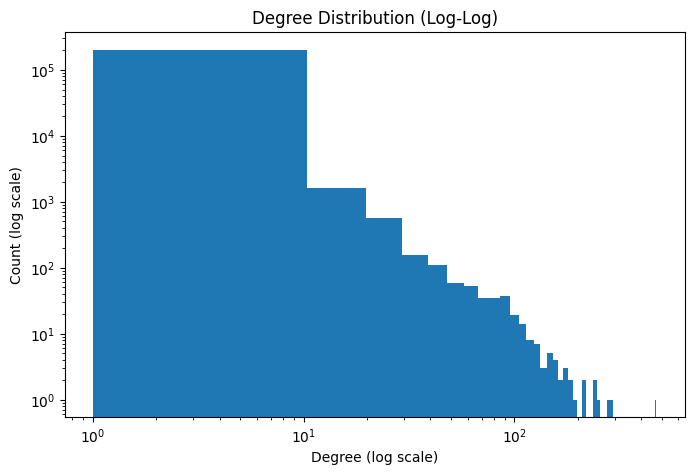

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df_features['degree'], bins=50)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Degree (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Degree Distribution (Log-Log)')
plt.show()

### Degree Summary Statistics

In [18]:
df_features['degree'].describe()

,degree
count,203769.000000
mean,2.300203
std,4.328377
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,473.000000


The mean degree is only 2.30, while the maximum degree reaches 473. This large difference indicates the presence of a small number of highly connected nodes within the network. Most transactions participate in only a few connections, while a small subset acts as hubs.

### Degree by Label

In [19]:
df_features.groupby('label')['degree'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
illicit,4545.0,2.011661,7.177521,1.0,1.0,1.0,2.0,177.0
licit,42019.0,3.095219,7.782942,1.0,1.0,2.0,3.0,473.0
unknown,157205.0,2.096047,2.528148,1.0,1.0,2.0,2.0,212.0


Licit transactions exhibit a higher average degree than illicit transactions. In addition, the highest-degree nodes in the network are primarily associated with licit transactions. This suggests that highly connected nodes are not necessarily indicative of illicit activity.

While illicit transactions tend to have slightly lower connectivity on average, degree alone is unlikely to fully separate illicit and licit behavior. Additional graph-based features will likely be needed to capture more complex network structure.

<Axes: xlabel='label', ylabel='degree'>

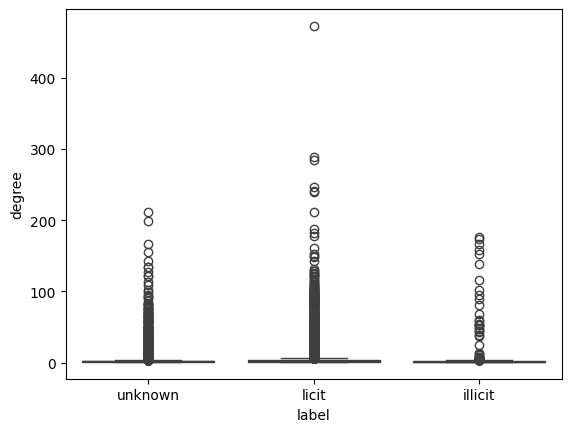

In [20]:
sns.boxplot(
    data=df_features[df_features['label'] != 0],
    x = 'label',
    y = 'degree')

### Degree and Time Step

To investigate potential temporal leakage, the Spearman correlation between degree and time_step was computed.

In [21]:
corr, p = spearmanr(
    df_features['degree'],
    df_features['time_step'])
print(corr)

-0.1058683979769241


The correlation is weak and negative. This suggests that degree is not strongly associated with the temporal ordering of transactions. Therefore, degree does not appear to act as a strong proxy for time and is less likely to introduce substantial temporal leakage into downstream models.

## Clustering Coefficient

The clustering coefficient meansures:

"How connected are my neighbors to each other?"

A high clustering coefficient indicates that a node's neighbors are densely connected, formain local triangle sturcures. A low clustering coefficient indicates that neighbors are largely discennected.

In [22]:
# local clustering coeffiecient
clustering = nx.clustering(G)

# add a DataFrame
df_features['clustering_coefficient'] = (
    df_features['txId'].map(clustering))

The resulting features colums contains the local clustering coefficient for each transaction node in the network.

### Clustering Coefficient Distribution

<Axes: xlabel='clustering_coefficient', ylabel='Count'>

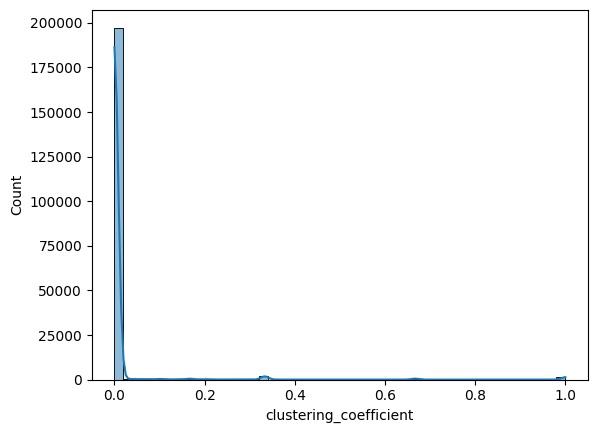

In [23]:
sns.histplot(
    df_features['clustering_coefficient'],
    bins=50,
    kde=True)

The distribution if highly concentrated near zero. Approximately 200,000 nodes have clustering coefficients close to zero, while reatively few nodes exhibit large values.

This suggests that most transactions do not perticipate in locally dense triangular sturctures. Only a small subset of nodes exhibit strong local clustering.

#### Log-Log Distribution for Clustering Coefficient

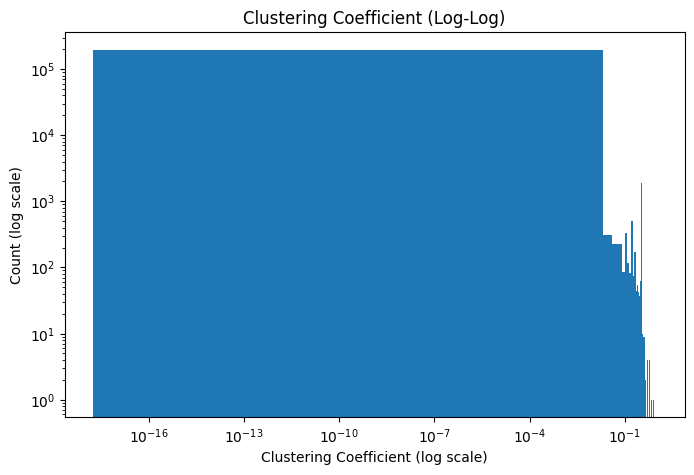

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df_features['clustering_coefficient'], bins=50)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Clustering Coefficient (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Clustering Coefficient (Log-Log)')
plt.show()

Unlike degree distribution, clustering coefficients are bounded between 0 and 1 and contain a large number of zero values. As a result, the log-log representation is difficult to interpret and provides limited additional insight.

For this feature, the standard histogram is more informative than the log-log visualization.

### Clustering Coefficient Summary Statistics

In [25]:
df_features['clustering_coefficient'].describe()

,clustering_coefficient
count,203769.000000
mean,0.013762
std,0.097304
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


The median clustering coefficient is zero, and the 75th percentile is also zero. This indicates that at least 75% of transaction nodes do not perticipate in local triangle structures.

Although most nodes have clustering coefficients near zero, a small number of highly clustered nodes increase the mean to approximately 0.014.

Overall, the network appears to be dominated by sparse local neighborhoods rather that densely connected communities.

### Clustering Coeffiecient by Label

In [26]:
df_features.groupby('label')['clustering_coefficient'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
illicit,4545.0,0.000356,0.015846,0.0,0.0,0.0,0.0,1.0
licit,42019.0,0.008320,0.073124,0.0,0.0,0.0,0.0,1.0
unknown,157205.0,0.015604,0.104018,0.0,0.0,0.0,0.0,1.0


The average clustering coefficient differs across labels.

Illicit transactions exhibit the lowest average clustering coefficient, while unknown transactions exhibit the highest. In addition, the standard deviation increases from illicit to licit to unknown transactions, indicating greater variability in local network structure.

These results suggest that illicit transaction tend to occur in sparser local neighborhoods that licit or unknown transactions. However, all three groups remain heavily concentrated near zero, so the practical separation between classes may be limited.

### Clustering Coeffiecient and Time Step

In [27]:
clustering_time = (
    df_features.groupby('time_step')['clustering_coefficient']
    .mean()
    .reset_index()
)

<Axes: xlabel='time_step', ylabel='clustering_coefficient'>

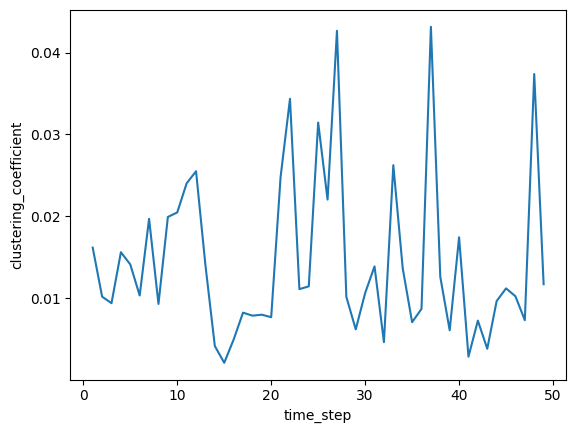

In [28]:
sns.lineplot(
    data=clustering_time,
    x='time_step',
    y='clustering_coefficient')

The average clustering coefficient varies across time steps and does not exhibit a clear monotonic trend. Instead, the metric fluctuates throughout the observation period, with several local peaks and valleys.

This suggests that local transaction structure changes over time, although the overall magnitude remains relatively small. Additional statistical testing would be required to determine whether these fluctuations represent meaningful temporal drift or normal variation within the network.

## PageRank

### What is PageRank?

PageRank was originally developed to rank websites by measuring the importance of a webpage based on the links pointing to it. In a transaction network, PageRank measures the relative importance of a node based on its connections to other nodes.

In [29]:
# compute pagerank
pagerank = nx.pagerank(G)

# add features to dataframe
df_features['pagerank']=(
    df_features['txId'].map(pagerank))

The resulting feature column contains the PageRank score for each transaction node in the network.

### PageRank Distribution

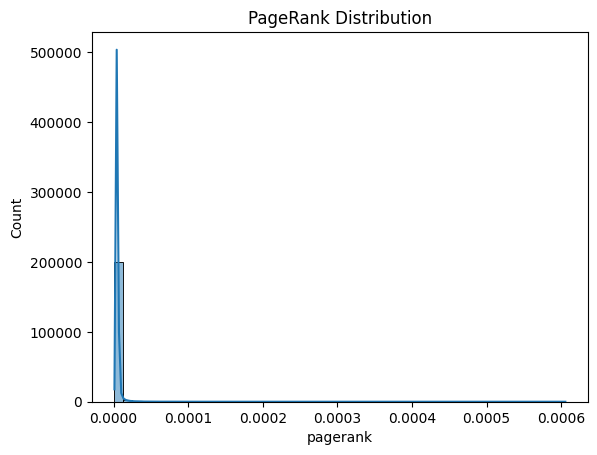

In [30]:
sns.histplot(df_features['pagerank'], bins=50, kde=True)
plt.title('PageRank Distribution')
plt.show()

The PageRank distribution is highly concentrated near zero. Most nodes have very small PageRank values, while a relatively small number of nodes have larger values, producing a long right tail.

#### PageRank for Log-Log

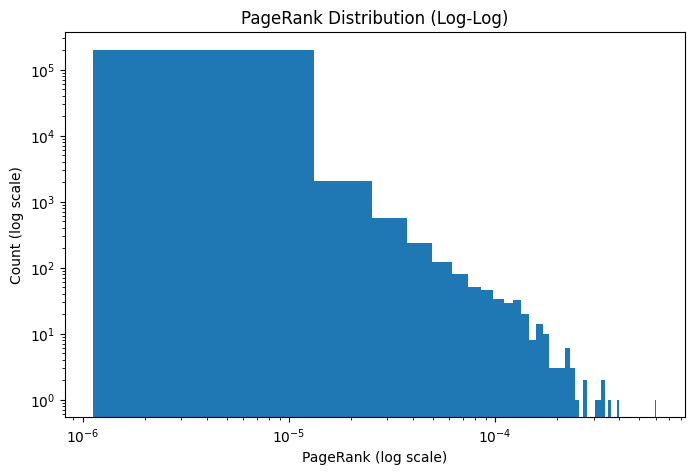

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df_features['pagerank'], bins=50)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('PageRank (log scale)')
plt.ylabel('Count (log scale)')
plt.title('PageRank Distribution (Log-Log)')
plt.show()

The log-log plot makes the long-tailed structure more visible. Most nodes have PageRank values between approximately $10^{-6}$ and $10^{-5}$, while only a small number of nodes have substantially larger PageRank scores.

### PageRank Summary Statistics

In [32]:
df_features['pagerank'].describe()

,pagerank
count,203769.000000
mean,0.000005
std,0.000006
min,0.000001
25%,0.000003
50%,0.000005
75%,0.000005
max,0.000606


The PageRank values are generally very small, with a median of 0.000005 and a maximum of 0.000606. The mean and median are similar, indicating that most nodes occupy comparable positions in the network, although a small number of nodes exhibit substantially higher PageRank values.

### PageRank by Label

In [33]:
df_features.groupby('label')['pagerank'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
illicit,4545.0,0.000005,0.000010,0.000001,0.000003,0.000003,0.000005,0.000238
licit,42019.0,0.000006,0.000011,0.000001,0.000003,0.000004,0.000006,0.000606
unknown,157205.0,0.000005,0.000003,0.000001,0.000003,0.000005,0.000005,0.000320


The average PageRank values are similar across all three labels. Licit transactions exhibit a slightly higher mean PageRank than illicit transactions, but the difference is small.

The standard deviations for illicit and licit transactions are also similar, suggesting comparable variation in node importance across the two groups.

Overall, PageRank appears to provide limited separation between illicit and licit transactions when considered as a standalone feature.

### PageRank by Time Step

<Axes: xlabel='time_step', ylabel='pagerank'>

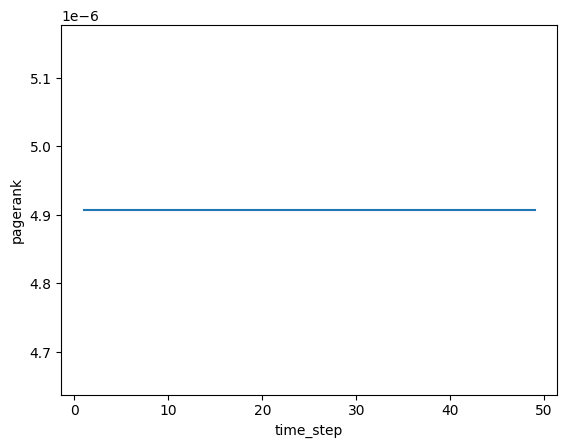

In [34]:
pagerank_time = (
    df_features.groupby('time_step')['pagerank'].mean().reset_index())

sns.lineplot(data=pagerank_time, x='time_step', y='pagerank')



The average PageRank remains nearly constant across time steps. Unlike Degree and Clustering Coefficient, there is little evidence of temporal variation in this feature.

This suggests that the overall importance structure of the transaction network remains relatively stable throughout the observation period.

### PageRank Correlation with Label



In [35]:
df_known_labels = df_features[df_features['label'] != 'unknown'].copy()

df_known_labels['label_binary'] = df_known_labels['label'].map({'illicit': 1, 'licit': 0})

spearmanr(df_known_labels['pagerank'], df_known_labels['label_binary'])

SignificanceResult(statistic=np.float64(-0.09306920085342059), pvalue=np.float64(4.344806251118011e-90))

Result:

- Spearman correlation: $-0.093$
- p-value: $4.34 \times 10^{⁻90}$

The Spearman correlation is negative but weak in magnitude. This indicates that higher PageRank values are associated with a slightly lower probability of belonging to the illicit class.

Although the relationship is statistically significant, the effect size is small. Therefore, PageRank alone is unlikely to be a strong predictor of illicit activity.

Overall, PageRank appears to provide substantially weaker class separation than Degree and Clustering Coefficient in the Elliptic dataset.

## Eigenvector Centrality

### What is Eigenvector Centrality?

Eigenvector centrality measures the importance of a node based on the importance of its neighbors. A node receives a high eigenvector score if it is connected to other nodes that also have high eigenvector scores.

In a fraud detection network, eigenvector centrality may help identify transactions that are connected to influential regions of the graph.

In [36]:
# compute eigenvector centrality
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

# add feature to dataframe
df_features['eigenvector_centrality'] = (df_features['txId'].map(eigenvector))

The resulting feature column contains the eigenvector centrality score for each transaction node.

### Eigenvector Distribution

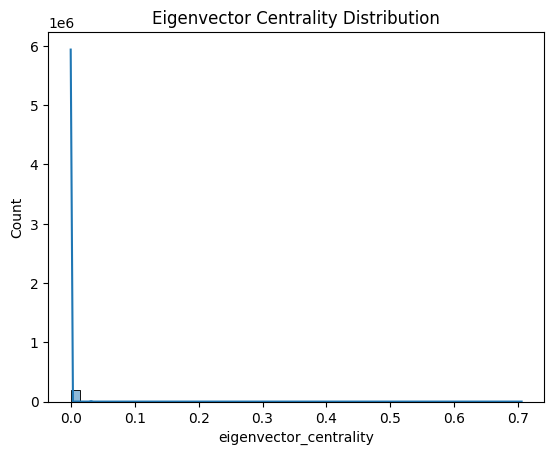

In [37]:
sns.histplot(df_features['eigenvector_centrality'], bins=50, kde=True)

plt.title('Eigenvector Centrality Distribution')
plt.show()

The distribution is highly concentrated near zero, with a small number of nodes exhibiting substantially larger values. This produces a long right tail extending to approximately 0.705.

This suggests that most transactions occupy relatively unimportant positions in the network, while only a small subset of nodes are highly connected to influential regions of the graph.

#### Eigenvector Log-Log Distribution

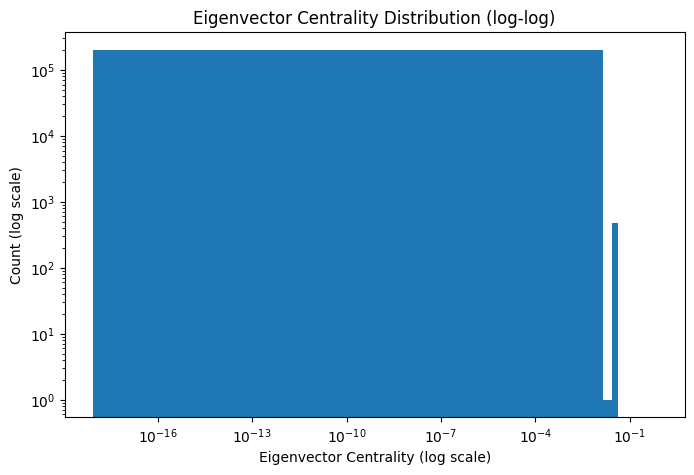

In [38]:
plt.figure(figsize=(8,5))

plt.hist(df_features['eigenvector_centrality'], bins=50)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Eigenvector Centrality (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Eigenvector Centrality Distribution (log-log)')
plt.show()

The log-log representation is difficult to interpret because most observations are concentrated extremely close to zero. Although the long tail remains visible, the standard histogram provides a clearer view of the overall distribution.


### Eigenvector Centrality Summary Statistics

In [39]:
df_features['eigenvector_centrality'].describe()

,eigenvector_centrality
count,2.037690e+05
mean,8.497364e-05
std,2.213667e-03
min,2.180014e-44
25%,5.611944e-23
50%,7.185132e-18
75%,1.501903e-14
max,7.051570e-01


The median and upper quartiles are extremely close to zero, indicating that most nodes have very low eigenvector centrality. However, the large gap between the minimum and maximum values suggests that a small number of nodes occupy substantially more influential positions within the network.

### Eigenvector by Label

In [40]:
df_features.groupby('label')['eigenvector_centrality'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
illicit,4545.0,0.000001,0.000044,2.076926e-43,1.615517e-23,7.828094e-19,5.592230e-16,0.002058
licit,42019.0,0.000379,0.004795,2.180014e-44,4.676632e-21,8.800432e-17,6.938259e-14,0.705157
unknown,157205.0,0.000009,0.000420,2.180014e-44,1.687058e-23,3.930994e-18,9.625249e-15,0.041914


The average eigenvector centrality differs across labels.

- Illicit mean: 0.000001
- Licit mean: 0.000379
- Unknown mean: 0.000009

Licit transactions exhibit substantially higher average eigenvector centrality than illicit transactions. The maximum eigenvector centrality is also considerably larger for licit transactions (0.705) than for illicit transactions (0.002).

These results suggest that licit transactions are more likely to occupy influential positions within the transaction network, although the overall values remain small and the distributions are heavily concentrated near zero.


### Eigenvector by Time Step

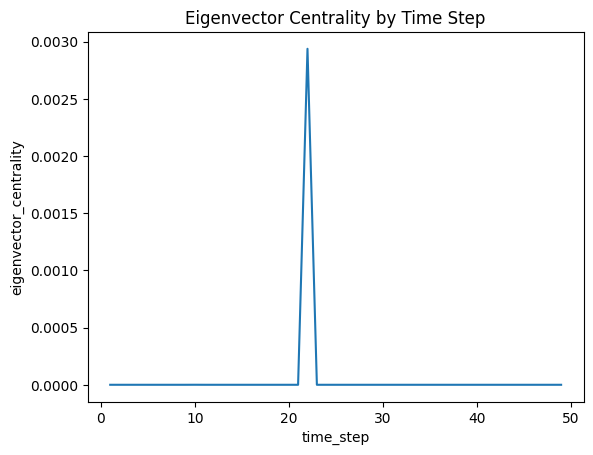

In [41]:
eigen_time = (df_features.groupby('time_step')['eigenvector_centrality'].mean().reset_index())

sns.lineplot(data=eigen_time, x='time_step', y='eigenvector_centrality')

plt.title('Eigenvector Centrality by Time Step')
plt.show()

The average eigenvector centrality remains close to zero across most time steps. While there is a noticeable spike around time step 22, the feature does not exhibit a clear monotonic trend over time.

This suggests that network influence varies throughout the observation period, but there is limited evidence of systematic temporal drift.

### Eigenvector Centrality Correlation with Label

In [42]:
df_known_labels = (df_features[df_features['label'] != 'unknown'].copy())

df_known_labels['label_binary'] = (df_known_labels['label'].map({'illicit':1, 'licit':0}))

spearmanr(df_known_labels['eigenvector_centrality'], df_known_labels['label_binary'])

SignificanceResult(statistic=np.float64(-0.12058320754977532), pvalue=np.float64(2.468338731042902e-150))

Results:

- Spearman Correlation: $-0.12$
- p-value: $2.47 \times 10^{-150}$

The Spearman correlation is negative and statistically significant. However, the magnitude of the correlation is relatively small.

This suggests that higher eigenvector centrality is associated with a slightly lower probability of belonging to the illicit class. Although the relationship is stronger than the corresponding PageRank result, the effect size remains weak.

Overall, eigenvector centrality appears to provide modest class separation, but it is unlikely to be a strong standalone predictor of illicit activity.

## Key Findings

This notebook established a clean baseline for fraud detection using a strict temporal train-validation-test split and a small set of graph-based features.

The baseline models demonstrated that fraud detection remains feasible under temporal validation. Logistic Regression achieved moderate performance, while Random Forest achieved substantially stronger performance on the validation set.

Among the graph features examined, Degree and Clustering Coefficient provided the strongest separation between transaction classes. Eigenvector Centrality showed modest signal, while PageRank exhibited relatively weak separation and remained largely stable across time steps.

Temporal analysis of the graph features did not reveal the strong monotonic patterns observed in the earlier leakage investigation. However, the strong Random Forest performance suggests that additional investigation of potential shortcut signals remains warranted.

Overall, the results indicate that simple graph structure contains useful information for fraud detection and provides a defensible baseline before introducing more complex graph feature engineering or graph neural network models.

The next stage of the project will focus on graph feature engineering, including neighborhood-based features, community structure, and directed graph experiments, while continuing to monitor potential sources of information leakage.

### Next Steps

Completed
- ✓ Leakage Investigation
- ✓ Baseline Machine Learning

Next
- □ Graph Feature Engineering
- □ Graph Neural Networks
- □ Topological Data Analysis